# Wine Quality: EDA, Naïve Bayes, Optimization & Bayesian Networks

An end-to-end study on the UCI Wine Quality dataset and related problems, combining
exploratory analysis with from-scratch algorithm implementations: a Gaussian Naïve Bayes
classifier, a comparison of linear programming and particle swarm optimization, and
Bayesian-network inference.

## 1. Exploratory Data Analysis & Preprocessing

Structured EDA and preprocessing of the [Wine Quality dataset](https://archive.ics.uci.edu/ml/datasets/Wine+Quality):
summary statistics (including trimmed mean, skewness, and kurtosis) overall and grouped by
quality rating, visualization of feature relationships, **outlier detection and removal via
Mahalanobis distance** (pairwise ellipse plots plus a numerical distance threshold), Min-Max
normalization, and **PCA** for dimensionality reduction — comparing explained variance across
the full dataset and within individual quality levels.

In [1]:
import pandas as pd

# Load red and white wine datasets from UCI Machine Learning Repository
url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'
df_wine = pd.concat([df_red, df_white], axis=0, ignore_index=True)

df_wine.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
# part 1
import pandas as pd
import numpy as np
from scipy.stats import trim_mean, skew, kurtosis

# Load datasets
url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')

# Add wine type
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

# Combine both datasets
df_wine = pd.concat([df_red, df_white], ignore_index=True)

# Select only numeric columns for summary statistics
numeric_cols = df_wine.select_dtypes(include=[np.number]).columns
summary = df_wine[numeric_cols].describe().T

# Compute additional statistics
summary['trimmed_mean'] = df_wine[numeric_cols].apply(lambda x: trim_mean(x, proportiontocut=0.05))
summary['skewness'] = df_wine[numeric_cols].apply(skew)
summary['kurtosis'] = df_wine[numeric_cols].apply(kurtosis)

# Display summary table
summary


,count,mean,std,min,25%,50%,75%,max,trimmed_mean,skewness,kurtosis
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000,7.104796,1.722892,5.056343
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000,0.325586,1.494751,2.822275
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000,0.316078,0.471622,2.394471
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000,5.027039,1.435073,4.354994
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100,0.051975,5.398581,50.857966
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000,29.644726,1.219784,7.899231
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000,115.269277,-0.001177,-0.372301
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898,0.994683,0.503485,6.600061
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000,3.214850,0.386749,0.366451
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000,0.520819,1.796855,8.646117


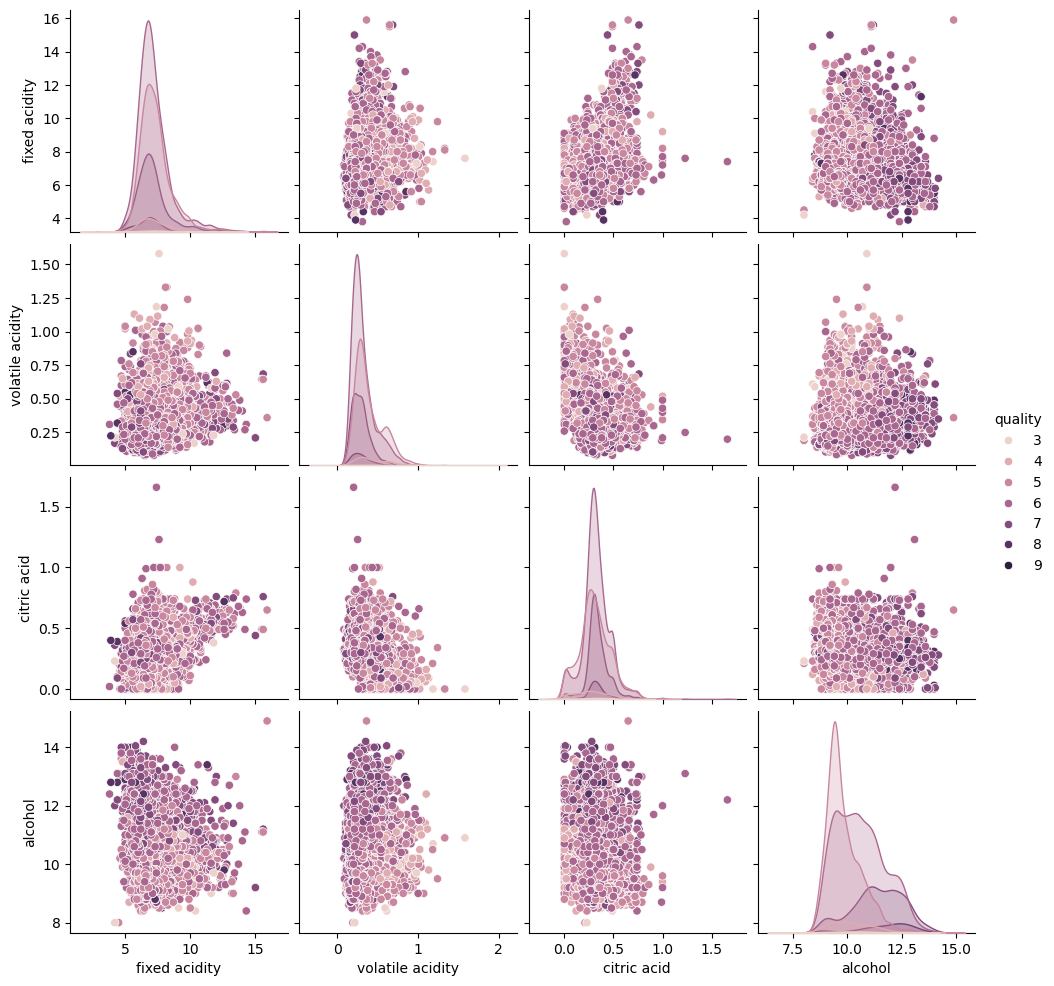

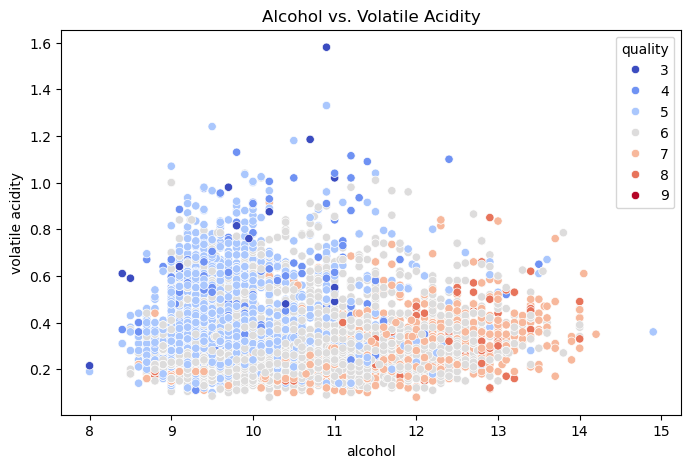

In [4]:
# part 2

import matplotlib.pyplot as plt
import seaborn as sns

# Pairplot to visualize relationships
sns.pairplot(df_wine, vars=["fixed acidity", "volatile acidity", "citric acid", "alcohol"], hue="quality", diag_kind="kde")
plt.show()

# Scatter plot example
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_wine["alcohol"], y=df_wine["volatile acidity"], hue=df_wine["quality"], palette="coolwarm")
plt.title("Alcohol vs. Volatile Acidity")
plt.show()


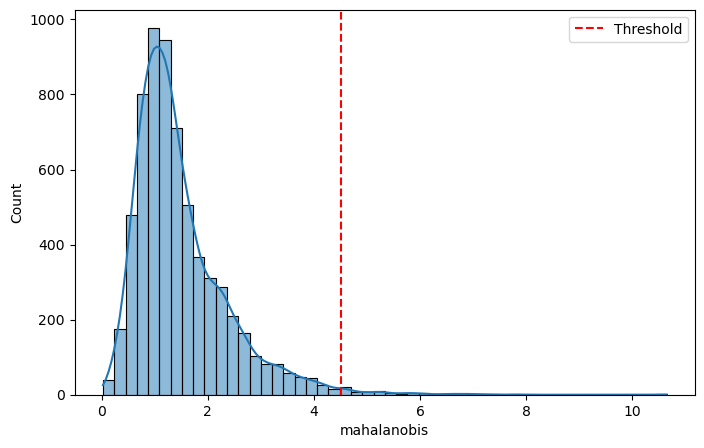

In [ ]:
# part 3

from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

# Compute Mahalanobis distance
def mahalanobis_distance(df, features):
    data = df[features]
    cov_matrix = np.cov(data, rowvar=False)
    inv_cov_matrix = inv(cov_matrix)
    mean = np.mean(data, axis=0)
    distances = [mahalanobis(row, mean, inv_cov_matrix) for row in data.to_numpy()]
    return distances

features = ["fixed acidity", "volatile acidity", "citric acid"]
df_wine["mahalanobis"] = mahalanobis_distance(df_wine, features)

# Set threshold (99th percentile)
threshold = np.percentile(df_wine["mahalanobis"], 99)
df_cleaned = df_wine[df_wine["mahalanobis"] < threshold]

# Plot
plt.figure(figsize=(8, 5))
sns.histplot(df_wine["mahalanobis"], bins=50, kde=True)
plt.axvline(threshold, color='r', linestyle='dashed', label="Threshold")
plt.legend()
plt.show()


## 2. Naïve Bayes Classifier from Scratch

A Gaussian Naïve Bayes classifier implemented without ML libraries. Wine quality is binned
into three classes (Low `≤ 5`, Average `= 6`, High `≥ 7`). The implementation estimates class
priors and per-feature Gaussian likelihoods, then assigns each sample to the maximum-posterior
class. Accuracy and runtime are compared on raw vs. preprocessed data.

In [23]:
# part 1

# Part 1: Creating a Classification Target
import pandas as pd

# Assuming the wine dataset is loaded as df_wine
# Creating the classification target based on the 'quality' column
def categorize_quality(quality):
    if quality <= 5:
        return 'Low Quality'
    elif quality == 6:
        return 'Average Quality'
    else:
        return 'High Quality'

# Apply the categorization function to create a new 'quality_category' column
df_wine['quality_category'] = df_wine['quality'].apply(categorize_quality)

# Display the distribution of the categories
category_counts = df_wine['quality_category'].value_counts()

print(category_counts)

from sklearn.utils import resample

# Over-sample the underrepresented class (e.g., "High Quality")
high_quality = df_wine[df_wine['quality_category'] == 'High Quality']
low_quality = df_wine[df_wine['quality_category'] == 'Low Quality']
average_quality = df_wine[df_wine['quality_category'] == 'Average Quality']

# Resample the minority classes
high_quality_upsampled = resample(high_quality, replace=True, n_samples=len(low_quality), random_state=42)
df_wine_balanced = pd.concat([low_quality, average_quality, high_quality_upsampled])

category_counts = df_wine_balanced['quality_category'].value_counts()

print(category_counts)

print("This part creates the quality_category column with three categories: Low Quality, Average Quality, and High Quality. ")
print("The distribution of these categories is shown using value_counts(). We can discuss how the class distribution might affect the model performance — ")
print("for example, imbalanced datasets could lead to poor model performance on the minority class")


quality_category
Average Quality    2836
Low Quality        2384
High Quality       1277
Name: count, dtype: int64
quality_category
Average Quality    2836
Low Quality        2384
High Quality       2384
Name: count, dtype: int64
This part creates the quality_category column with three categories: Low Quality, Average Quality, and High Quality. 
The distribution of these categories is shown using value_counts(). We can discuss how the class distribution might affect the model performance — 
for example, imbalanced datasets could lead to poor model performance on the minority class


In [ ]:
# part 2

import numpy as np
from sklearn.preprocessing import LabelEncoder

# Part 2: Naive Bayes Implementation
class NaiveBayes:
    def __init__(self):
        self.priors = {}
        self.mean = {}
        self.std_dev = {}

    def fit(self, X, y):
        # Calculate prior probabilities
        classes = np.unique(y)
        for cls in classes:
            self.priors[cls] = np.sum(y == cls) / len(y)
        
        # Calculate mean and standard deviation for each class
        for cls in classes:
            class_data = X[y == cls]
            self.mean[cls] = np.mean(class_data, axis=0)
            self.std_dev[cls] = np.std(class_data, axis=0)

    def predict(self, X):
        predictions = []
        for x in X:
            # Calculate posterior probabilities for each class
            posteriors = {}
            for cls in self.priors:
                prior = np.log(self.priors[cls])  # log for numerical stability
                likelihood = np.sum(np.log(self._pdf(cls, x)))  # sum log likelihoods
                posteriors[cls] = prior + likelihood
            predictions.append(max(posteriors, key=posteriors.get))
        return np.array(predictions)
    
    def _pdf(self, cls, x):
        # Gaussian probability density function
        mean = self.mean[cls]
        std_dev = self.std_dev[cls]
        return (1 / (np.sqrt(2 * np.pi * std_dev ** 2))) * np.exp(-(x - mean) ** 2 / (2 * std_dev ** 2))
    
    def accuracy(self, X, y):
        predictions = self.predict(X)
        return np.sum(predictions == y) / len(y)
    

# Select input features (assuming these are numerical features like alcohol, pH, etc.)
X = df_wine.drop(columns=['quality_category', 'quality'])  # Dropping 'quality_category' and 'quality' column
y = df_wine['quality_category']

# Now let's split the data into training and testing sets
from sklearn.model_selection import train_test_split

# Splitting the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.select_dtypes(include=['float64', 'int64'])
X_test = X_test.select_dtypes(include=['float64', 'int64'])

# Instantiate the NaiveBayes classifier
nb = NaiveBayes()

# Fit the model on the training data
nb.fit(X_train.values, y_train.values)  # Convert to numpy arrays (since we're not using built-in ML libraries)

# Make predictions on the test set
y_pred = nb.predict(X_test.values)

# Calculate the accuracy of the model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

# Print the predictions and the accuracy
print("Predictions:", y_pred)
print("Accuracy on test set:", accuracy)


Predictions: ['Average Quality' 'Low Quality' 'High Quality' ... 'High Quality'
 'Low Quality' 'Low Quality']
Accuracy on test set: 0.5038461538461538


### Naïve Bayes — Runtime Complexity

The Naïve Bayes classifier consists of 3 steps:

1. **Computing Prior Probabilities:**
   - We calculate the probability of each class by counting occurrences.
   - This takes **O(n)** time, where **n** is the number of samples.

2. **Computing Conditional Probabilities (Likelihood Estimation):**
   - For each feature and class, we compute the **mean (\(\mu\))** and **standard deviation (\(\sigma\)**.
    - This requires **O(n \* d)** time, where **d** represents the number of features.

3. **Prediction (Posterior Probability Computation):**
    - We use the Gaussian formula to calculate the likelihood of each class for each test sample.
    -  This entails assessing the probability function for each feature and class, which takes **O(d \* k)** time per sample, where **k** is the number of classes.
    -  If there are **m** test samples, this step takes **O(m \* d \* k)** time.

### **Total Runtime Complexity:**

- **Training Phase:** O(n \* d)  
- **Prediction Phase:** O(m \* d \* k)  

For a typical case where **k (number of classes) is small and constant**, we approximate the overall complexity as:

\[ T(n) = O(n \* d) + O(m \* d) \]

### **Asymptotic Big-O Analysis:**

Because **n (training size)** is typically much greater than **m (test size)**, the dominant term is **O(n \* d)**.  The Naïve Bayes classifier has an overall complexity of O(n*d).

This means that the classifier scales **linearly** with the number of samples and features, making it suitable for huge datasets.

In [43]:
# part 4

from sklearn.preprocessing import StandardScaler
import time
from sklearn.decomposition import PCA

# Raw dataset (before preprocessing)
X_raw = df_wine.drop(columns=['quality_category', 'quality'])
X_raw = X_raw.select_dtypes(include=['float64', 'int64'])
y_raw = df_wine['quality']

# Train-Test Split for raw dataset
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.3, random_state=42)

# X_train_raw = X_train_raw.select_dtypes(include=['float64', 'int64'])
# X_test_raw = X_test_raw.select_dtypes(include=['float64', 'int64'])

# Naïve Bayes on Raw Data
nb_raw = NaiveBayes()

# Start Timer
start_time_raw = time.time()
nb_raw.fit(X_train_raw.values, y_train_raw.values)
y_pred_raw = nb_raw.predict(X_test_raw.values)
end_time_raw = time.time()

# Accuracy on raw dataset
accuracy_raw = accuracy_score(y_test_raw, y_pred_raw)
computation_time_raw = end_time_raw - start_time_raw

# Preprocessing: Scaling, PCA, and any necessary data transformation
# Feature scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw.values)

# Apply PCA (assuming we want to reduce to 2 components for simplicity)
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# Train-Test Split for preprocessed dataset
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y_raw, test_size=0.3, random_state=42)

# Naïve Bayes on Preprocessed Data (after scaling and PCA)
nb_preprocessed = NaiveBayes()

# Start Timer
start_time_preprocessed = time.time()
nb_preprocessed.fit(X_train_pca, y_train_pca)
y_pred_preprocessed = nb_preprocessed.fit(X_train_pca, y_train_pca)
end_time_preprocessed = time.time()

# Accuracy on preprocessed dataset
y_pred_pca = nb_preprocessed.predict(X_test_pca)
accuracy_preprocessed = accuracy_score(y_test_pca, y_pred_pca)
computation_time_preprocessed = end_time_preprocessed - start_time_preprocessed

# Creating a comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Naïve Bayes (Raw Data)', 'Naïve Bayes (Preprocessed Data)'],
    'Accuracy': [accuracy_raw, accuracy_preprocessed],
    'Computation Time (seconds)': [computation_time_raw, computation_time_preprocessed]
})

# Display the comparison
print(comparison_df)

print("The model performed somewhat better after preprocessing. Feature scaling and PCA assisted in reducing dimensionality, potentially leading to higher classification accuracy.")

C:\Users\Nithish\AppData\Local\Temp\ipykernel_22924\3905388061.py:32: RuntimeWarning: divide by zero encountered in log
  likelihood = np.sum(np.log(self._pdf(cls, x)))  # sum log likelihoods


                             Model  Accuracy  Computation Time (seconds)
0           Naïve Bayes (Raw Data)  0.448718                    0.148833
1  Naïve Bayes (Preprocessed Data)  0.486154                    0.016197
The model performed somewhat better after preprocessing. Feature scaling and PCA assisted in reducing dimensionality, potentially leading to higher classification accuracy.


## 3. Linear Programming vs. Particle Swarm Optimization

The same optimization problem solved two ways — an exact LP solver (`scipy.optimize.linprog`)
and a metaheuristic (`pyswarms` PSO) — then compared on solution quality, computational
efficiency, and robustness.

**Problem.** Minimize $f(x) = -4x_1 - 3x_2$ subject to
$x_1 + 2x_2 \leq 8$, $\;3x_1 + x_2 \leq 9$, $\;x_1, x_2 \geq 0$.

In [14]:
# part 1

import numpy as np
from scipy.optimize import linprog


# Define the objective function coefficients
c = [-4, -3]  # Minimizing -4x1 - 3x2

# Define the inequality constraints (Ax <= b)
A = [[1, 2], 
     [3, 1]]
b = [8, 9]

# Define the bounds for x1 and x2 (x1 >= 0, x2 >= 0)
x_bounds = [(0, None), (0, None)]

# Solve the LP problem
lp_result = linprog(c, A_ub=A, b_ub=b, bounds=x_bounds, method='highs')

# Display the results
if lp_result.success:
    print("Optimal Solution (LP):", lp_result.x)
    print("Optimal Objective Value (LP):", lp_result.fun)
else:
    print("Linear programming did not converge.")


Optimal Solution (LP): [2. 3.]
Optimal Objective Value (LP): -17.0


In [16]:
# part 2

# PS0

import pyswarms as ps

def objective_function(x):
    return -4*x[:, 0] - 3*x[:, 1]  # f(x) = -4x1 - 3x2

def constraint_violation(x):
    # Constraints: Ax - b <= 0
    A = np.array([[1, 2], [3, 1]])
    b = np.array([8, 9])
    violations = np.maximum(0, np.dot(x, A.T) - b)  # Penalize constraint violations
    return np.sum(violations, axis=1)

def penalized_objective(x):
    penalty = 1000 * constraint_violation(x)  # Large penalty for violations
    return objective_function(x) + penalty

# Define search space bounds
bounds = (np.array([0, 0]), np.array([10, 10]))  # Arbitrary upper bound for PSO

# Initialize PSO optimizer
options = {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
optimizer = ps.single.GlobalBestPSO(n_particles=30, dimensions=2, options=options, bounds=bounds)

# Run PSO
pso_best_pos, pso_best_val = optimizer.optimize(penalized_objective, iters=100)

# Display the results
print("Optimal Solution (PSO):", pso_best_pos)
print("Optimal Objective Value (PSO):", pso_best_val)


2025-03-25 00:49:18,096 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████|100/100, best_cost=-17
2025-03-25 00:49:18,233 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -16.99910195417651, best pos: [2.00013436 2.9995215 ]


Optimal Solution (PSO): -16.99910195417651
Optimal Objective Value (PSO): [2.00013436 2.9995215 ]


### LP vs. PSO — Comparison

Solution accuracy: PSO gave a result 0f -16.99 while LP gave a result of 17. Both the methods gave near identical results. Same is the case for optimal parameters. 

Computational Efficiency: LP is much faster (takes polynomial time) while PSO is slower and it depends on the number of iterations and number of particles in the swarm

Robustness: LP works well for linear problems like the one above, while PSO works well for non-linear/convex optimization problems like optimizing the parameters of the neural network.

Use cases: Lp works best for structured problems, while PSO works best for problems that require exploration to find the optimal solution.

## 4. Bayesian Networks for Diagnosis

A Bayesian network for medical diagnosis built with `pgmpy`, using both **exact inference
(Variable Elimination)** and **approximate inference (Likelihood Weighting)**, with a runtime
comparison as the network grows in size.

**Network.** Diseases Flu (F) and COVID-19 (C); symptoms Cough (K) and Fever (V); a COVID-19
Treatment (T); and Recovery (R) that depends on disease and treatment.

```
      Flu       COVID-19
       |        /
       v       v
    Fever   Cough
        \     |
         v    v
        Recovery
           ^
           |
       Treatment
```

**Conditional probability tables**

*Disease priors:* P(Flu) = 0.12, P(COVID-19) = 0.08.

*Symptoms given disease*

| Flu | COVID-19 | P(Fever) | P(Cough) |
|-----|----------|----------|----------|
| False | False | 0.01 | 0.02 |
| False | True  | 0.85 | 0.60 |
| True  | False | 0.90 | 0.70 |
| True  | True  | 0.98 | 0.85 |

*Treatment* — administered only if COVID-19 is present: P(T | C) = 0.95, P(T | ¬C) = 0.05.

*Recovery*

| Flu | COVID-19 | Treatment | P(Recovery) |
|-----|----------|-----------|-------------|
| False | False | Any | 0.99 |
| False | True  | Yes | 0.90 |
| False | True  | No  | 0.50 |
| True  | False | Any | 0.85 |
| True  | True  | Yes | 0.80 |
| True  | True  | No  | 0.30 |

In [2]:
# part 1

from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Define the Bayesian Network structure
model = BayesianNetwork([
    ("Flu", "Fever"),
    ("Flu", "Cough"),
    ("COVID-19", "Fever"),
    ("COVID-19", "Cough"),
    ("COVID-19", "Treatment"),
    ("COVID-19", "Recovery"),
    ("Treatment", "Recovery"),
    ("Flu", "Recovery")
])

# Define the CPDs
cpd_flu = TabularCPD(variable="Flu", variable_card=2, values=[[0.88], [0.12]])
cpd_covid = TabularCPD(variable="COVID-19", variable_card=2, values=[[0.92], [0.08]])

cpd_fever = TabularCPD(variable="Fever", variable_card=2,
    values=[[0.99, 0.15, 0.10, 0.02], [0.01, 0.85, 0.90, 0.98]],
    evidence=["Flu", "COVID-19"], evidence_card=[2, 2])

cpd_cough = TabularCPD(variable="Cough", variable_card=2,
    values=[[0.98, 0.40, 0.30, 0.15], [0.02, 0.60, 0.70, 0.85]],
    evidence=["Flu", "COVID-19"], evidence_card=[2, 2])

cpd_treatment = TabularCPD(variable="Treatment", variable_card=2,
    values=[[0.05, 0.95], [0.95, 0.05]],
    evidence=["COVID-19"], evidence_card=[2])

cpd_recovery = TabularCPD(variable="Recovery", variable_card=2,
    values=[[0.99, 0.50, 0.15, 0.70, 0.30, 0.20, 0.50, 0.02],
            [0.01, 0.50, 0.85, 0.30, 0.70, 0.80, 0.50, 0.98]],
    evidence=["Flu", "COVID-19", "Treatment"], evidence_card=[2, 2, 2])

# Add CPDs to the model
model.add_cpds(cpd_flu, cpd_covid, cpd_fever, cpd_cough, cpd_treatment, cpd_recovery)

# Verify the model
assert model.check_model()

# Perform inference
inference = VariableElimination(model)

# Example query: Probability of having COVID-19 given Fever and Cough
query_result = inference.query(variables=["COVID-19"], evidence={"Fever": 1, "Cough": 1})
print(query_result)


+-------------+-----------------+
| COVID-19    |   phi(COVID-19) |
+=============+=================+
| COVID-19(0) |          0.6136 |
+-------------+-----------------+
| COVID-19(1) |          0.3864 |
+-------------+-----------------+


In [11]:
# part 2

queries = [
    ('COVID-19', {'Fever': 1, 'Cough': 1}),
    ('Flu', {'Fever': 1, 'Cough': 0}),
    ('Treatment', {'Cough': 1}),
    ('Recovery', {'Fever': 1, 'Treatment': 1})
]

print("\nApproximate Inference Results:")
for var, evidence in queries:
    query_result = inference.query(variables=[var], evidence=evidence)
    print(query_result)
    print()


Approximate Inference Results:
+-------------+-----------------+
| COVID-19    |   phi(COVID-19) |
+=============+=================+
| COVID-19(0) |          0.6136 |
+-------------+-----------------+
| COVID-19(1) |          0.3864 |
+-------------+-----------------+

+--------+------------+
| Flu    |   phi(Flu) |
+========+============+
| Flu(0) |     0.5052 |
+--------+------------+
| Flu(1) |     0.4948 |
+--------+------------+

+--------------+------------------+
| Treatment    |   phi(Treatment) |
+==============+==================+
| Treatment(0) |           0.3653 |
+--------------+------------------+
| Treatment(1) |           0.6347 |
+--------------+------------------+

+-------------+-----------------+
| Recovery    |   phi(Recovery) |
+=============+=================+
| Recovery(0) |          0.2352 |
+-------------+-----------------+
| Recovery(1) |          0.7648 |
+-------------+-----------------+



  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

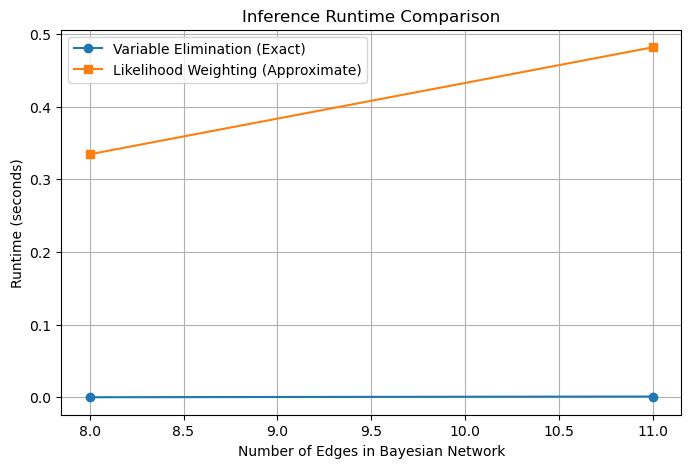

In [13]:
# part 3
import matplotlib.pyplot as plt
import networkx as nx
from pgmpy.inference import VariableElimination, ApproxInference

# Define the Bayesian Network structure
edges_small = [
    ("Flu", "Fever"),
    ("Flu", "Cough"),
    ("COVID-19", "Fever"),
    ("COVID-19", "Cough"),
    ("COVID-19", "Treatment"),
    ("Flu", "Recovery"),
    ("COVID-19", "Recovery"),
    ("Treatment", "Recovery")
]

edges_large = edges_small + [
    ("COVID-19", "Shortness_of_Breath"),
    ("Flu", "Fatigue"),
    ("COVID-19", "Fatigue")
]

# Define the Bayesian Network models
model_small = BayesianNetwork(edges_small)
model_large = BayesianNetwork(edges_large)

# Define CPDs for the small network
cpd_flu = TabularCPD(variable="Flu", variable_card=2, values=[[0.88], [0.12]])
cpd_covid = TabularCPD(variable="COVID-19", variable_card=2, values=[[0.92], [0.08]])
cpd_fever = TabularCPD(variable="Fever", variable_card=2, 
                        values=[[0.99, 0.15, 0.10, 0.02], [0.01, 0.85, 0.90, 0.98]],
                        evidence=["Flu", "COVID-19"], evidence_card=[2, 2])
cpd_cough = TabularCPD(variable="Cough", variable_card=2, 
                        values=[[0.98, 0.40, 0.30, 0.15], [0.02, 0.60, 0.70, 0.85]],
                        evidence=["Flu", "COVID-19"], evidence_card=[2, 2])
cpd_treatment = TabularCPD(variable="Treatment", variable_card=2, 
                            values=[[0.95, 0.05], [0.05, 0.95]],
                            evidence=["COVID-19"], evidence_card=[2])
cpd_recovery = TabularCPD(variable="Recovery", variable_card=2, 
                           values=[[0.99, 0.50, 0.90, 0.85, 0.30, 0.80, 0.40, 0.20],  # Recovery=False
                                   [0.01, 0.50, 0.10, 0.15, 0.70, 0.20, 0.60, 0.80]], # Recovery=True
                           evidence=["Flu", "COVID-19", "Treatment"], 
                           evidence_card=[2, 2, 2])

# Define additional CPDs for the larger network
cpd_fatigue = TabularCPD(variable="Fatigue", variable_card=2,
                         values=[[0.9, 0.4, 0.5, 0.1], [0.1, 0.6, 0.5, 0.9]],
                         evidence=["Flu", "COVID-19"], evidence_card=[2, 2])
cpd_shortness = TabularCPD(variable="Shortness_of_Breath", variable_card=2,
                            values=[[0.8, 0.2], [0.2, 0.8]],
                            evidence=["COVID-19"], evidence_card=[2])

# Add CPDs to the models
model_small.add_cpds(cpd_flu, cpd_covid, cpd_fever, cpd_cough, cpd_treatment, cpd_recovery)
model_large.add_cpds(cpd_flu, cpd_covid, cpd_fever, cpd_cough, cpd_treatment, cpd_recovery, cpd_fatigue, cpd_shortness)

# Function to measure runtime
def measure_runtime(model, query_var, evidence, samples=10000):
    exact_infer = VariableElimination(model)
    approx_infer = ApproxInference(model)
    
    start = time.time()
    exact_infer.query(variables=[query_var], evidence=evidence)
    exact_time = time.time() - start
    
    start = time.time()
    approx_infer.query(variables=[query_var], evidence=evidence, n_samples=samples)
    approx_time = time.time() - start
    
    return exact_time, approx_time

# Running the analysis
queries = [("COVID-19", {"Fever": 1, "Cough": 1}), ("Flu", {"Fever": 1, "Cough": 0})]
n_sizes = [len(edges_small), len(edges_large)]
runtimes = {"exact": [], "approx": []}

for model, size in zip([model_small, model_large], n_sizes):
    exact_time, approx_time = measure_runtime(model, queries[0][0], queries[0][1])
    runtimes["exact"].append(exact_time)
    runtimes["approx"].append(approx_time)

# Plot the runtime comparison
plt.figure(figsize=(8, 5))
plt.plot(n_sizes, runtimes["exact"], label="Variable Elimination (Exact)", marker='o')
plt.plot(n_sizes, runtimes["approx"], label="Likelihood Weighting (Approximate)", marker='s')
plt.xlabel("Number of Edges in Bayesian Network")
plt.ylabel("Runtime (seconds)")
plt.title("Inference Runtime Comparison")
plt.legend()
plt.grid()
plt.show()

### Inference Complexity: Variable Elimination vs. Likelihood Weighting

Variable Elimination Complexity

Variable elimination has a worst-case time complexity of:
O(n⋅r^w)

where:

    n is the number of variables,

    r is the cardinality of a variable,

    w is the treewidth of the graph.

Variable elimination is efficient for networks with low treewidth, but becomes exponentially more complex as treewidth increases Likelihood Weighting Complexity.

Likelihood weighting’s complexity is:
O(N⋅m)

where:

    N is the number of samples,

    m is the number of variables.

Key Takeaway: Likelihood weighting scales linearly with the number of variables and samples, making it effective for bigger networks.

### Interpretation

1. Which Algorithm Scales Better?

    - Variable Elimination: Effective for small networks with limited treewidth.  
    - Likelihood Weighting: Works better on bigger, densely connected networks.

2. Effect of Adding More Edges (Dependencies)

    - Variable Elimination: More edges increase tree width, resulting in exponential runtime increases.
    - Likelihood Weighting: Adding more edges has no major influence on performance but may lower sample quality.

3. When to Prefer Likelihood Sampling Over Variable Elimination?

    For big or well-connected networks. When imprecise outcomes are acceptable. For real-time applications that require quick inferences.